In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,event_DFS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,32.909589,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,27.715068,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,43.101370,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,47.473973,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,41.490411,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,36.821918,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,40.043836,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,40.964384,0


In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 95])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

## Standardization for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

In [19]:
X_numeric

,age,pack_years,SUVpeak,MTV,TLG
0,54.238356,0.000000,14.473272,7.934,86.228420
1,54.539726,27.404795,5.044678,1.656,7.040100
2,59.019178,41.019178,7.839043,14.502,83.569669
3,70.726027,37.500000,2.880631,2.440,5.567091
4,67.865753,53.000000,5.402006,3.668,16.150550
...,...,...,...,...,...
134,60.435616,0.000000,9.290139,3.650,26.280140
135,68.794521,0.000000,7.172883,18.967,101.754834
136,57.498630,39.498630,13.873187,6.370,66.273201
137,65.684932,71.527397,7.507419,12.443,71.832443


In [20]:
X_std

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG
0,0.365347,1,0,1,0,0,1,0.0,0,0.000000,0.0,0.435155,0.074159,0.044798
1,0.373041,0,0,0,0,1,0,0.0,1,0.213981,0.0,0.089331,0.008512,0.001900
2,0.487409,0,1,0,0,0,1,0.0,1,0.320284,1.0,0.191823,0.142839,0.043358
3,0.786304,0,0,0,0,1,0,0.0,1,0.292806,0.0,0.009957,0.016710,0.001102
4,0.713276,0,0,0,0,1,0,0.0,1,0.413832,0.0,0.102437,0.029551,0.006835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,0.523573,0,0,1,0,0,1,1.0,0,0.000000,0.0,0.245047,0.029363,0.012323
135,0.736989,0,0,1,0,0,1,1.0,0,0.000000,1.0,0.167389,0.189529,0.053209
136,0.448587,0,0,1,0,0,1,1.0,1,0.308411,0.0,0.413145,0.057805,0.033988
137,0.657597,0,0,1,0,0,1,1.0,1,0.558497,1.0,0.179660,0.121309,0.037000


## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

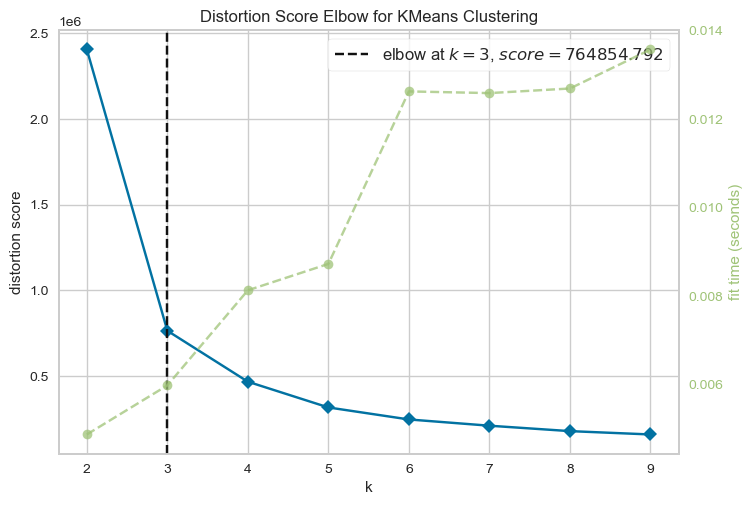

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [22]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(3):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=3)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: TLG, Coefficient: -3.792227067649884


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: hpv_related, Coefficient: -1.229060383408114


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 2: Most important feature: uicc8_III-IV, Coefficient: 0.9468001854559268


In [23]:
X_fs_fi = X.loc[:, selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Standardization

In [24]:
# Copy the original X for later 
original_X = X.copy()

In [25]:
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Standardize X_new, the new data with the selected features only 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
X_new_std = X_new_std[X_new.columns]

In [26]:
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [27]:
X_new

,TLG,hpv_related,uicc8_III-IV
0,86.228420,0.0,0.0
1,7.040100,0.0,0.0
2,83.569669,0.0,1.0
3,5.567091,0.0,0.0
4,16.150550,0.0,0.0
...,...,...,...
134,26.280140,1.0,0.0
135,101.754834,1.0,1.0
136,66.273201,1.0,0.0
137,71.832443,1.0,1.0


In [28]:
X_new_std

,TLG,hpv_related,uicc8_III-IV
0,0.044798,0.0,0.0
1,0.001900,0.0,0.0
2,0.043358,0.0,1.0
3,0.001102,0.0,0.0
4,0.006835,0.0,0.0
...,...,...,...
134,0.012323,1.0,0.0
135,0.053209,1.0,1.0
136,0.033988,1.0,0.0
137,0.037000,1.0,1.0


In [29]:
MAASTRO_new

,TLG,hpv_related,uicc8_III-IV
0,263.611623,1,0
1,36.980700,0,1
2,74.636342,0,1
3,46.791979,0,1
4,107.637514,1,0
...,...,...,...
94,144.490782,0,1
95,69.214868,0,1
96,102.594274,1,1
97,103.229492,1,0


In [30]:
MAASTRO_new_std

,TLG,hpv_related,uicc8_III-IV
0,0.140892,1,0
1,0.018119,0,1
2,0.038519,0,1
3,0.023434,0,1
4,0.056396,1,0
...,...,...,...
94,0.076361,0,1
95,0.035582,0,1
96,0.053664,1,1
97,0.054008,1,0


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [31]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-21 15:25:09,707] A new study created in memory with name: no-name-8850bb8a-a364-4afe-9ecb-dc7ee65f6064


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-21 15:25:09,899] A new study created in memory with name: no-name-e6f0badc-af3e-46f5-a7fc-6ab8715b6a10


Fold 1 C-index: 0.5871559633027523
Fold 2 C-index: 0.6292682926829268
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:09,894] Trial 0 finished with value: 0.6056609717345188 and parameters: {}. Best is trial 0 with value: 0.6056609717345188.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6056609717345188], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 9, 791251), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 9, 894008), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6056609717345188


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23112257499736208
Fold 2 IBS: 0.2481143926240285
Fold 3 IBS: 0.26122246510498537
[I 2024-04-21 15:25:10,223] Trial 0 finished with value: 0.246819810908792 and parameters: {}. Best is trial 0 with value: 0.246819810908792.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.246819810908792], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 9, 943196), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 10, 223498), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.246819810908792


In [32]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [33]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.606
train_ibs:  0.247


#### Test

In [34]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [35]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.659
IBS score: 0.214


In [36]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [37]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [38]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-21 15:25:10,701] A new study created in memory with name: no-name-5d2a04c6-739c-42ae-a36d-ca233790a869


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-21 15:25:11,021] A new study created in memory with name: no-name-32c1f424-cef4-4e44-96e3-050444973eb1


Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:10,984] Trial 0 finished with value: 0.6270584207211263 and parameters: {}. Best is trial 0 with value: 0.6270584207211263.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6270584207211263], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 10, 765948), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 10, 984607), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6270584207211263


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24820216511906806
Fold 2 IBS: 0.23351868144825097
Fold 3 IBS: 0.23466234456715074
[I 2024-04-21 15:25:11,319] Trial 0 finished with value: 0.23879439704482328 and parameters: {}. Best is trial 0 with value: 0.23879439704482328.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23879439704482328], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 11, 91085), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 11, 319732), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23879439704482328


In [39]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [40]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.627
train_ibs:  0.239


#### Test

In [41]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [42]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.601


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.224


In [43]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [44]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-21 15:25:11,971] A new study created in memory with name: no-name-288d13e0-37fa-44db-bdb3-a3997b7fd76b


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-21 15:25:12,336] A new study created in memory with name: no-name-ed275a6a-9b9d-4ae2-9ff9-bff6eb50d0ed


Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6536585365853659
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:12,328] Trial 0 finished with value: 0.6192519529916446 and parameters: {}. Best is trial 0 with value: 0.6192519529916446.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6192519529916446], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 12, 80449), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 12, 328136), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6192519529916446


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23022234150029328
Fold 2 IBS: 0.24708835777468222
Fold 3 IBS: 0.260500984401541
[I 2024-04-21 15:25:12,674] Trial 0 finished with value: 0.24593722789217218 and parameters: {}. Best is trial 0 with value: 0.24593722789217218.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24593722789217218], datetime_start=datetime.datetime(2024, 4, 21, 15, 25, 12, 404257), datetime_complete=datetime.datetime(2024, 4, 21, 15, 25, 12, 674308), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24593722789217218


In [45]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [46]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.619
train_ibs:  0.246


#### Test

In [47]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [48]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.601


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.214


In [49]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [50]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-21 15:25:13,032] A new study created in memory with name: no-name-1f775c17-a65d-4a2d-9514-8cb151daf46e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.656910569105691
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:13,553] Trial 0 finished with value: 0.6203359638317529 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6203359638317529.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6601626016260163
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:13,932] Trial 1 finished with value: 0.6214199746718614 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.6214199746718614.
Fold 1 C-index: 0.5871559633027523
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:14,531] Trial 2 finished with value: 0.6097260123849253 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 1 with value: 0.6214199746718614.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6585365853658537
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:14,980] Trial 3 finished with value: 

Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:21,107] Trial 30 finished with value: 0.6270584207211263 and parameters: {'l1_ratio': 0.07378617237655391}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:21,204] Trial 31 finished with value: 0.6270584207211263 and parameters: {'l1_ratio': 0.00017278083149219192}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.5871559633027523
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:21,305] Trial 32 finished with value: 0.6215975207648136 and parameters: {'l1_ratio': 0.1474007120432645}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.5871559633027523
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:21,604] Trial 33 finished w

Fold 2 C-index: 0.656910569105691
Fold 3 C-index: 0.6005586592178771
[I 2024-04-21 15:25:27,444] Trial 60 finished with value: 0.6203359638317529 and parameters: {'l1_ratio': 0.6105468804291476}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:27,510] Trial 61 finished with value: 0.6270584207211263 and parameters: {'l1_ratio': 0.0027977141100857805}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:27,625] Trial 62 finished with value: 0.6270584207211263 and parameters: {'l1_ratio': 0.06223825987835301}. Best is trial 10 with value: 0.6270584207211263.
Fold 1 C-index: 0.6035386631716907
Fold 2 C-index: 0.6414634146341464
Fold 3 C-index: 0.6361731843575419
[I 2024-04-21 15:25:27,725] Trial 63 finished with value: 0.6270584207211263 and par

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.23013237987041513
Fold 2 IBS: 0.24700472423668646
Fold 3 IBS: 0.26046430598830794
[I 2024-04-21 15:25:33,187] Trial 0 finished with value: 0.24586713669846985 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24586713669846985.
Fold 1 IBS: 0.23002882149745166
Fold 2 IBS: 0.24673274428226805
Fold 3 IBS: 0.2603701629321948
[I 2024-04-21 15:25:33,537] Trial 1 finished with value: 0.24571057623730486 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.24571057623730486.
Fold 1 IBS: 0.23002082423644826
Fold 2 IBS: 0.23221962165887086
Fold 3 IBS: 0.26038211958240537
[I 2024-04-21 15:25:33,817] Trial 2 finished with value: 0.24087418849257483 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.24087418849257483.
Fold 1 IBS: 0.23008258143635463
Fold 2 IBS: 0.2468527698419894
Fold 3 IBS: 0.26042430668749733
[I 2024-04-21 15:25:34,148] Trial 3 finished with value: 0.24578655265528046 and paramet

Fold 3 IBS: 0.26036870797544714
[I 2024-04-21 15:25:42,176] Trial 30 finished with value: 0.24081673653708688 and parameters: {'l1_ratio': 0.26354748336763617}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.23018664929505098
Fold 2 IBS: 0.23265914500932458
Fold 3 IBS: 0.23193424593116083
[I 2024-04-21 15:25:42,545] Trial 31 finished with value: 0.2315933467451788 and parameters: {'l1_ratio': 0.12743723849083632}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.23021110779465384
Fold 2 IBS: 0.23237170389276363
Fold 3 IBS: 0.2603622452580309
[I 2024-04-21 15:25:42,902] Trial 32 finished with value: 0.24098168564848277 and parameters: {'l1_ratio': 0.18760729600841888}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.2461170545230674
Fold 2 IBS: 0.23303059596245004
Fold 3 IBS: 0.23309818584444228
[I 2024-04-21 15:25:43,024] Trial 33 finished with value: 0.23741527877665325 and parameters: {'l1_ratio': 0.06561436876377445}. Best is trial 16 

Fold 1 IBS: 0.2302459759162845
Fold 2 IBS: 0.232592754374845
Fold 3 IBS: 0.2317269879088367
[I 2024-04-21 15:25:51,193] Trial 61 finished with value: 0.23152190606665543 and parameters: {'l1_ratio': 0.14011865127967174}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.24509777976446212
Fold 2 IBS: 0.23279818971486407
Fold 3 IBS: 0.23236853940296104
[I 2024-04-21 15:25:51,383] Trial 62 finished with value: 0.23675483629409574 and parameters: {'l1_ratio': 0.10267591506959375}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.24726549200850012
Fold 2 IBS: 0.23329798793205184
Fold 3 IBS: 0.2339485000547051
[I 2024-04-21 15:25:51,606] Trial 63 finished with value: 0.23817065999841902 and parameters: {'l1_ratio': 0.027993917803963486}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.23001084689444895
Fold 2 IBS: 0.2466849006112118
Fold 3 IBS: 0.2604181784975402
[I 2024-04-21 15:25:51,923] Trial 64 finished with value: 0.24570464200106698 and par

Fold 1 IBS: 0.23020007808785897
Fold 2 IBS: 0.23256481293269501
Fold 3 IBS: 0.23163971697466174
[I 2024-04-21 15:25:58,963] Trial 91 finished with value: 0.23146820266507193 and parameters: {'l1_ratio': 0.1456460359630974}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.24496262688054588
Fold 2 IBS: 0.23276785199610833
Fold 3 IBS: 0.2322737030505642
[I 2024-04-21 15:25:59,082] Trial 92 finished with value: 0.23666806064240611 and parameters: {'l1_ratio': 0.10789070915990566}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.2302512865823661
Fold 2 IBS: 0.23241150440383948
Fold 3 IBS: 0.2603920890330792
[I 2024-04-21 15:25:59,357] Trial 93 finished with value: 0.24101829333976157 and parameters: {'l1_ratio': 0.17834591278686074}. Best is trial 16 with value: 0.23144652094967388.
Fold 1 IBS: 0.23024527613248547
Fold 2 IBS: 0.23250968916707077
Fold 3 IBS: 0.26035544760983653
[I 2024-04-21 15:25:59,652] Trial 94 finished with value: 0.24103680430313093 and p

In [51]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [52]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.627
train_ibs:  0.231


#### Test

In [53]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [54]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.09799455604980911)

test_cindex : 0.601


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.14964037380709083)

test_ibs:  0.214


In [55]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [56]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-21 15:26:00,874] A new study created in memory with name: no-name-a7d5a8cf-108c-414a-998c-da0d0f929ddd


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6218872870249017
Fold 2 C-index: 0.5829268292682926
Fold 3 C-index: 0.5300279329608939
[I 2024-04-21 15:26:04,248] Trial 0 finished with value: 0.5782806830846962 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5782806830846962.
Fold 1 C-index: 0.6422018348623854
Fold 2 C-index: 0.6178861788617886
Fold 3 C-index: 0.5928770949720671
[I 2024-04-21 15:26:06,798] Trial 1 finished with value: 0.6176550362320804 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.11413161543947781, 'warm_start': False}. Best is trial 1 with value: 0.617655036232080

Fold 1 C-index: 0.6159895150720839
Fold 2 C-index: 0.7869918699186992
Fold 3 C-index: 0.6319832402234636
[I 2024-04-21 15:26:30,341] Trial 17 finished with value: 0.6783215417380822 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 7, 'n_estimators': 71, 'oob_score': True, 'max_samples': 0.9859343634257625, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.3637168382811743, 'warm_start': True}. Best is trial 14 with value: 0.7005504568305603.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
[I 2024-04-21 15:26:30,465] Trial 18 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 19, 'max_depth': 4, 'n_estimators': 21, 'oob_score': True, 'max_samples': 0.46049775905454604, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.38335524316027697, 'warm_start': True}. Best is trial 14 with value: 0.7005504568305603.
Fold 1 C-index: 0.5760157273918742
Fold 2 C-index: 0.79

Fold 1 C-index: 0.6205766710353866
Fold 2 C-index: 0.8016260162601626
Fold 3 C-index: 0.6899441340782123
[I 2024-04-21 15:26:44,865] Trial 34 finished with value: 0.7040489404579205 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 6, 'min_samples_leaf': 8, 'max_depth': 17, 'n_estimators': 128, 'oob_score': True, 'max_samples': 0.7659566751211386, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.14316267699000676, 'warm_start': True}. Best is trial 34 with value: 0.7040489404579205.
Fold 1 C-index: 0.6153342070773263
Fold 2 C-index: 0.8195121951219512
Fold 3 C-index: 0.6836592178770949
[I 2024-04-21 15:26:46,053] Trial 35 finished with value: 0.7061685400254575 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 19, 'n_estimators': 186, 'oob_score': True, 'max_samples': 0.7948212261000067, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.13796700701129333, 'warm_start': True}. Best is trial 35 with value: 0.7061685400254

Fold 1 C-index: 0.6231979030144168
Fold 2 C-index: 0.8495934959349594
Fold 3 C-index: 0.776536312849162
[I 2024-04-21 15:27:17,103] Trial 51 finished with value: 0.7497759039328461 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 14, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 335, 'oob_score': False, 'max_samples': 0.8395177451586797, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.023842999171346406, 'warm_start': True}. Best is trial 43 with value: 0.7586119362112517.
Fold 1 C-index: 0.6146788990825688
Fold 2 C-index: 0.8422764227642277
Fold 3 C-index: 0.7905027932960894
[I 2024-04-21 15:27:18,488] Trial 52 finished with value: 0.7491527050476287 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 436, 'oob_score': False, 'max_samples': 0.9525187236073195, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.05675029963315997, 'warm_start': True}. Best is trial 43 with value: 0.758611936

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
[I 2024-04-21 15:27:45,090] Trial 68 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 15, 'min_samples_leaf': 2, 'max_depth': 14, 'n_estimators': 469, 'oob_score': False, 'max_samples': 0.9075135261691765, 'max_features': None, 'min_weight_fraction_leaf': 0.48797001480189905, 'warm_start': True}. Best is trial 43 with value: 0.7586119362112517.
Fold 1 C-index: 0.6166448230668414
Fold 2 C-index: 0.7926829268292683
Fold 3 C-index: 0.638268156424581
[I 2024-04-21 15:27:46,633] Trial 69 finished with value: 0.6825319687735636 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 8, 'n_estimators': 398, 'oob_score': False, 'max_samples': 0.7318335045229435, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.29311322044618127, 'warm_start': True}. Best is trial 43 with value: 0.7586119362112517.
Fold 1 C-index: 0.6127129750982963
Fold 2 C-index: 0.849

KeyboardInterrupt: 

In [ ]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [ ]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [ ]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

In [ ]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [ ]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


In [ ]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [ ]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [ ]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

In [ ]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [ ]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

In [ ]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [ ]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [ ]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

In [ ]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [36]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-29 14:18:18,679] A new study created in memory with name: no-name-ec0f9855-4264-4cea-b273-44a8c7ed2f44


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:18,961] Trial 0 finished with value: 0.6542270796438157 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:21,263] Trial 1 finished with value: 0.6418764820342538 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.623574144486692
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:35,354] Trial 19 finished with value: 0.614616551607913 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.5915597174096103, 'n_estimators': 299, 'learning_rate': 0.08697733590757546}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6425855513307985
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:36,774] Trial 20 finished with value: 0.6439609199479982 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.7859448591953863, 'n_estimators': 408, 'learning_rate': 0.06348170552170027}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.623574144486692
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:51,154] Trial 38 finished with value: 0.614616551607913 and parameters: {'subsample': 0.8975124960092108, 'dropout_rate': 0.3454513035831812, 'n_estimators': 238, 'learning_rate': 0.050384430919465664}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:18:52,215] Trial 39 finished with value: 0.6542270796438157 and parameters: {'subsample': 0.7415710071500535, 'dropout_rate': 0.8737909302085629, 'n_estimators': 357, 'learning_rate': 0.01715036845928685}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold

...

Fold 2 IBS: 0.26284258297157914
Fold 3 IBS: 0.1989800856613979
Fold 4 IBS: 0.29406399992580307
Fold 5 IBS: 0.21248387140289904
[I 2024-04-29 14:19:55,869] Trial 19 finished with value: 0.25354040771132685 and parameters: {'subsample': 0.23213625139224725, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.04061015936667263}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.30684900542884236
Fold 2 IBS: 0.25192383155786524
Fold 3 IBS: 0.2078637322011128
Fold 4 IBS: 0.28932555979525265
Fold 5 IBS: 0.20877443500686252
[I 2024-04-29 14:19:56,267] Trial 20 finished with value: 0.2529473127979871 and parameters: {'subsample': 0.3923190305501453, 'dropout_rate': 0.30866564063362517, 'n_estimators': 150, 'learning_rate': 0.0817175642960023}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.2441681525534558
Fold 2 IBS: 0.22075175310610318
Fold 3 IBS: 0.20973940045873996
Fold 4 IBS: 0.2333464319888485
Fold 5 IBS: 0.2132781997207452
[I 2024-0

Fold 2 IBS: 0.256057452086359
Fold 3 IBS: 0.19822613504836567
Fold 4 IBS: 0.28263715353505725
Fold 5 IBS: 0.20830207207913842
[I 2024-04-29 14:20:01,488] Trial 38 finished with value: 0.248628419348157 and parameters: {'subsample': 0.30351722206014203, 'dropout_rate': 0.5151980307588179, 'n_estimators': 201, 'learning_rate': 0.05734665979046438}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.24641235459537686
Fold 2 IBS: 0.21875554397977218
Fold 3 IBS: 0.20770494601913075
Fold 4 IBS: 0.23610636591854287
Fold 5 IBS: 0.21051629762727775
[I 2024-04-29 14:20:01,590] Trial 39 finished with value: 0.22389910162802007 and parameters: {'subsample': 0.5193754320584076, 'dropout_rate': 0.3475958957014864, 'n_estimators': 39, 'learning_rate': 0.06892741183938003}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.32485536420111955
Fold 2 IBS: 0.256952582974877
Fold 3 IBS: 0.22506280672526405
Fold 4 IBS: 0.292679377563226
Fold 5 IBS: 0.21103043083704018
[I 2024-04-2

Fold 3 IBS: 0.1897475662967071
Fold 4 IBS: 0.25192144829137586
Fold 5 IBS: 0.20147726379147826
[I 2024-04-29 14:20:10,263] Trial 57 finished with value: 0.22508223511415074 and parameters: {'subsample': 0.2527801492312065, 'dropout_rate': 0.30223574172447776, 'n_estimators': 145, 'learning_rate': 0.04128616221999911}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.24558745382080374
Fold 2 IBS: 0.2300943775233059
Fold 3 IBS: 0.22606951680193696
Fold 4 IBS: 0.24139951306463375
Fold 5 IBS: 0.22715647203060052
[I 2024-04-29 14:20:10,344] Trial 58 finished with value: 0.23406146664825617 and parameters: {'subsample': 0.17365273956401148, 'dropout_rate': 0.47751452932312355, 'n_estimators': 17, 'learning_rate': 0.015264577280930194}. Best is trial 15 with value: 0.22295813189993052.
Fold 1 IBS: 0.24368277321008547
Fold 2 IBS: 0.2192959058192288
Fold 3 IBS: 0.2056547870352674
Fold 4 IBS: 0.23691685507376253
Fold 5 IBS: 0.2099383391000767
[I 2024-04-29 14:20:10,543] Trial 59 f

Fold 3 IBS: 0.19719564748013846
Fold 4 IBS: 0.24772469015390394
Fold 5 IBS: 0.2052178110254269
[I 2024-04-29 14:20:15,295] Trial 76 finished with value: 0.22286640028154675 and parameters: {'subsample': 0.27904930750778345, 'dropout_rate': 0.1748848456024778, 'n_estimators': 117, 'learning_rate': 0.03448067567102388}. Best is trial 75 with value: 0.22191233778529734.
Fold 1 IBS: 0.2438695512426696
Fold 2 IBS: 0.2199292205004089
Fold 3 IBS: 0.19444564719960716
Fold 4 IBS: 0.257878189162853
Fold 5 IBS: 0.20486845893137498
[I 2024-04-29 14:20:15,596] Trial 77 finished with value: 0.22419821340738272 and parameters: {'subsample': 0.20327733338523224, 'dropout_rate': 0.1742732170545178, 'n_estimators': 117, 'learning_rate': 0.038556655110269754}. Best is trial 75 with value: 0.22191233778529734.
Fold 1 IBS: 0.2416658652245594
Fold 2 IBS: 0.22513830722896386
Fold 3 IBS: 0.2157372644672027
Fold 4 IBS: 0.24490145917359488
Fold 5 IBS: 0.21881840941086575
[I 2024-04-29 14:20:15,704] Trial 78 fin

Fold 1 IBS: 0.239329655611398
Fold 2 IBS: 0.21862567074427813
Fold 3 IBS: 0.19603776007072418
Fold 4 IBS: 0.2494264284717085
Fold 5 IBS: 0.2101733670217877
[I 2024-04-29 14:20:21,742] Trial 96 finished with value: 0.22271857638397932 and parameters: {'subsample': 0.14413439953128043, 'dropout_rate': 0.12859654918121421, 'n_estimators': 46, 'learning_rate': 0.06413325090254297}. Best is trial 93 with value: 0.22004628263694456.
Fold 1 IBS: 0.2410212175869884
Fold 2 IBS: 0.21785168527254553
Fold 3 IBS: 0.1924128534293324
Fold 4 IBS: 0.2465815317467044
Fold 5 IBS: 0.20585246717845565
[I 2024-04-29 14:20:21,897] Trial 97 finished with value: 0.22074395104280525 and parameters: {'subsample': 0.132466709392393, 'dropout_rate': 0.15389272264093917, 'n_estimators': 58, 'learning_rate': 0.06159159949766198}. Best is trial 93 with value: 0.22004628263694456.
Fold 1 IBS: 0.23949050452255433
Fold 2 IBS: 0.22211251281874184
Fold 3 IBS: 0.20830528824757272
Fold 4 IBS: 0.24613750161927025
Fold 5 IBS:

In [37]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [ ]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [ ]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

In [ ]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

### Gradient boosting without standardization

In [31]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)
            
            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-29 14:15:47,228] A new study created in memory with name: no-name-5aa2d89a-568e-4106-9ea6-e823959729d1


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:15:47,589] Trial 0 finished with value: 0.6542270796438157 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:15:49,874] Trial 1 finished with value: 0.6418764820342538 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.623574144486692
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:16:03,623] Trial 19 finished with value: 0.614616551607913 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.5915597174096103, 'n_estimators': 299, 'learning_rate': 0.08697733590757546}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.4714828897338403
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:16:05,036] Trial 20 finished with value: 0.6097403876286066 and parameters: {'subsample': 0.38161734041406226, 'dropout_rate': 0.7859448591953863, 'n_estimators': 408, 'learning_rate': 0.06348170552170027}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold

Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.6787234042553192
Fold 4 C-index: 0.623574144486692
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:16:19,702] Trial 38 finished with value: 0.614616551607913 and parameters: {'subsample': 0.8975124960092108, 'dropout_rate': 0.3454513035831812, 'n_estimators': 238, 'learning_rate': 0.050384430919465664}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-29 14:16:20,784] Trial 39 finished with value: 0.6542270796438157 and parameters: {'subsample': 0.7415710071500535, 'dropout_rate': 0.8737909302085629, 'n_estimators': 357, 'learning_rate': 0.01715036845928685}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold

...

Fold 3 IBS: 0.2042401813746421
Fold 4 IBS: 0.24481763726215872
Fold 5 IBS: 0.20273780642810457
[I 2024-04-29 14:17:24,638] Trial 19 finished with value: 0.22704795005813275 and parameters: {'subsample': 0.94616158758761, 'dropout_rate': 0.24313988493838726, 'n_estimators': 141, 'learning_rate': 0.036212385990032875}. Best is trial 16 with value: 0.22344027544620232.
Fold 1 IBS: 0.2461281131705786
Fold 2 IBS: 0.23014087737194217
Fold 3 IBS: 0.22675245541530725
Fold 4 IBS: 0.24059853010038257
Fold 5 IBS: 0.22734892660559133
[I 2024-04-29 14:17:24,713] Trial 20 finished with value: 0.23419378053276038 and parameters: {'subsample': 0.7937505765635346, 'dropout_rate': 0.3783894910069867, 'n_estimators': 14, 'learning_rate': 0.017331004877487094}. Best is trial 16 with value: 0.22344027544620232.
Fold 1 IBS: 0.26959056119881664
Fold 2 IBS: 0.2190804014238466
Fold 3 IBS: 0.20413534790494076
Fold 4 IBS: 0.24721969331205532
Fold 5 IBS: 0.2021406477227881
[I 2024-04-29 14:17:25,095] Trial 21 fin

Fold 1 IBS: 0.2540752750684564
Fold 2 IBS: 0.21814554309198136
Fold 3 IBS: 0.20653312894433049
Fold 4 IBS: 0.23771891992688038
Fold 5 IBS: 0.2062208782572085
[I 2024-04-29 14:17:32,414] Trial 39 finished with value: 0.22453874905777144 and parameters: {'subsample': 0.7571342768554894, 'dropout_rate': 0.6881141432789704, 'n_estimators': 56, 'learning_rate': 0.06645154057879363}. Best is trial 16 with value: 0.22344027544620232.
Fold 1 IBS: 0.26076988694729336
Fold 2 IBS: 0.21993960187170153
Fold 3 IBS: 0.19967230492288884
Fold 4 IBS: 0.24200885729195745
Fold 5 IBS: 0.2023449050605336
[I 2024-04-29 14:17:32,718] Trial 40 finished with value: 0.22494711121887495 and parameters: {'subsample': 0.4567450560834594, 'dropout_rate': 0.5443446234145757, 'n_estimators': 111, 'learning_rate': 0.04645670522085161}. Best is trial 16 with value: 0.22344027544620232.
Fold 1 IBS: 0.2440825473905944
Fold 2 IBS: 0.22312907234357202
Fold 3 IBS: 0.21614799220102243
Fold 4 IBS: 0.2365347761487103
Fold 5 IBS

Fold 2 IBS: 0.295747195112126
Fold 3 IBS: 0.23624783872404376
Fold 4 IBS: 0.41804147646954687
Fold 5 IBS: 0.2300565369245491
[I 2024-04-29 14:17:37,207] Trial 58 finished with value: 0.3019492217539927 and parameters: {'subsample': 0.5212893383237698, 'dropout_rate': 0.7352789611442869, 'n_estimators': 376, 'learning_rate': 0.06338773913840043}. Best is trial 47 with value: 0.22223114999053473.
Fold 1 IBS: 0.2647306061672293
Fold 2 IBS: 0.22030997555686108
Fold 3 IBS: 0.19915708574256938
Fold 4 IBS: 0.24504779635102733
Fold 5 IBS: 0.20182575092842364
[I 2024-04-29 14:17:37,369] Trial 59 finished with value: 0.22621424294922216 and parameters: {'subsample': 0.4960596140344138, 'dropout_rate': 0.693800336122209, 'n_estimators': 72, 'learning_rate': 0.07539891699032558}. Best is trial 47 with value: 0.22223114999053473.
Fold 1 IBS: 0.28228051030408535
Fold 2 IBS: 0.2261223205228632
Fold 3 IBS: 0.20334128944949512
Fold 4 IBS: 0.25305715332645706
Fold 5 IBS: 0.20126391654226208
[I 2024-04-2

Fold 3 IBS: 0.20091418898494162
Fold 4 IBS: 0.2577336693449905
Fold 5 IBS: 0.20185496468142572
[I 2024-04-29 14:17:41,252] Trial 78 finished with value: 0.2355744066870348 and parameters: {'subsample': 0.5127715061180806, 'dropout_rate': 0.7983401004786739, 'n_estimators': 128, 'learning_rate': 0.061281908858944245}. Best is trial 47 with value: 0.22223114999053473.
Fold 1 IBS: 0.2443978931849229
Fold 2 IBS: 0.22697368453401853
Fold 3 IBS: 0.22016527737730995
Fold 4 IBS: 0.23740068434973668
Fold 5 IBS: 0.22276480171576776
[I 2024-04-29 14:17:41,324] Trial 79 finished with value: 0.2303404682323512 and parameters: {'subsample': 0.3678790866471354, 'dropout_rate': 0.8388878890494271, 'n_estimators': 11, 'learning_rate': 0.06710152034479298}. Best is trial 47 with value: 0.22223114999053473.
Fold 1 IBS: 0.2530916850816852
Fold 2 IBS: 0.21738942014917795
Fold 3 IBS: 0.2038136162817386
Fold 4 IBS: 0.23531770156476828
Fold 5 IBS: 0.20652508819901472
[I 2024-04-29 14:17:41,467] Trial 80 finis

Fold 4 IBS: 0.23782293873984045
Fold 5 IBS: 0.22315643976422783
[I 2024-04-29 14:17:47,335] Trial 97 finished with value: 0.23069238477459386 and parameters: {'subsample': 0.4877473818667499, 'dropout_rate': 0.7703567346376552, 'n_estimators': 11, 'learning_rate': 0.0664165860844942}. Best is trial 47 with value: 0.22223114999053473.
Fold 1 IBS: 0.24772050364996204
Fold 2 IBS: 0.21763842661809077
Fold 3 IBS: 0.20350425995111046
Fold 4 IBS: 0.23396892511930054
Fold 5 IBS: 0.20730562655933338
[I 2024-04-29 14:17:47,463] Trial 98 finished with value: 0.22202754837955946 and parameters: {'subsample': 0.4335488477703664, 'dropout_rate': 0.8992410902831605, 'n_estimators': 53, 'learning_rate': 0.06117624339488499}. Best is trial 98 with value: 0.22202754837955946.
Fold 1 IBS: 0.26512617218576046
Fold 2 IBS: 0.2227749631375082
Fold 3 IBS: 0.19698666593968076
Fold 4 IBS: 0.5594623102109119
Fold 5 IBS: 0.2014013751340709
[I 2024-04-29 14:17:47,694] Trial 99 finished with value: 0.28915029732158

In [32]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [33]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.654
train_ibs:  0.222


In [34]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [35]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3575254014553415,
                                              learning_rate=0.05558016213920623,
                                              n_estimators=114,
                                              random_state=123,
                                              subsample=0.7268222670380755)

C-index score: 0.601


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.8992410902831605,
                                              learning_rate=0.06117624339488499,
                                              n_estimators=53, random_state=123,
                                              subsample=0.4335488477703664)

IBS: 0.215


In [ ]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [ ]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

In [ ]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

In [ ]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

In [ ]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

In [ ]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/dfs/minmax/fs_fi/'  # Folder path where you want to save the files

# Modify the file names to match the desired format
modified_file_names = ['d1_dfs_minmax_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [ ]:
from datetime import date
today = date.today()
print("Date: ", today)